<a href="https://colab.research.google.com/github/surendrakoth/ImageRecognition/blob/main/ImageRecog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Milestone Two

**Data Preparation and Model Exploration**
**Due:** Midnight on November 16th with usual 2-hour grace period — **worth 100 points**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [ ]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os, time, math, random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.applications import mobilenet_v2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

# PIL for robust image I/O / conversions
from PIL import Image

# For generating cryptographic hashes of the image's raw byte data to check for exact file identity and integrity
import hashlib

# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds
results = {}
# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

# Config (image size and split ratios)
IMG_SIZE = 224
VAL_FRACTION = 0.10
TEST_FRACTION = 0.10
TRAIN_FRACTION = 1.0 - VAL_FRACTION - TEST_FRACTION
assert abs(TRAIN_FRACTION + VAL_FRACTION + TEST_FRACTION - 1.0) < 1e-6
BATCH_SIZE = 32
EPOCHS=100

In [ ]:
# ============================================
# Helper Functions (centralized)
# ============================================

# Convert to RGB to standardize channels and avoid mode issues
def _safe_to_rgb(img_pil):
    if img_pil.mode != "RGB":
        img_pil = img_pil.convert("RGB")
    return img_pil

# Resize to a fixed square size for stable tensors / batching
def _resize_to_square(img_pil, size=IMG_SIZE):
    return img_pil.resize((size, size), Image.BICUBIC)

# Normalize to float32 in [0,1] to stabilize training
def _to_float_array(img_pil):
    arr = np.asarray(img_pil, dtype=np.float32) / 255.0
    return arr

# Corruption check by attempting full preprocess; any exception -> drop
def is_corrupted(row):
    try:
        _ = _to_float_array(_resize_to_square(_safe_to_rgb(row["image"])))
        return False
    except Exception:
        return True

# Fast exact-duplicate hashing (pixel buffer)
def hash_image_fast(img_pil):
    return hashlib.md5(np.array(img_pil).tobytes()).hexdigest()

# Map function: produce standardized tensors for model input
def preprocess_no_aug(example):
    img = _to_float_array(_resize_to_square(_safe_to_rgb(example["image"])))
    return {"pixel_values": img, "label": example["label"]}

# Quick visual sanity check on a batched tf.data pipeline
def preview_batch(ds_tf, n=6, class_names=None):
    for xb, yb in ds_tf.take(1):
        xb, yb = xb.numpy(), yb.numpy()
        n = min(n, xb.shape[0])
        cols = 3
        rows = int(math.ceil(n / cols))
        plt.figure(figsize=(3*cols, 3*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            plt.imshow(xb[i])
            plt.axis("off")
            if class_names is not None:
                plt.title(class_names[int(yb[i])], fontsize=9)
        plt.tight_layout()
        plt.show()

In [ ]:
# Load Food-101 from Hugging Face
food_all = load_dataset("food101", split="train+validation")
label_col = "label"

# Verify schema & cache label names
assert label_col in food_all.features
assert isinstance(food_all.features[label_col], ClassLabel)
food_label_names = food_all.features[label_col].names

print(f"[Load] Total images: {len(food_all):,} | Classes: {len(food_label_names)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[Load] Total images: 101,000 | Classes: 101


[Load] Total images: 101,000 | Classes: 101
[Features]: ['image', 'label']
[First 3 entries (id → name, size)]:
  row 0: id=  6  name=beignets                  image_size=(384, 512)
  row 1: id=  6  name=beignets                  image_size=(512, 512)
  row 2: id=  6  name=beignets                  image_size=(512, 383)


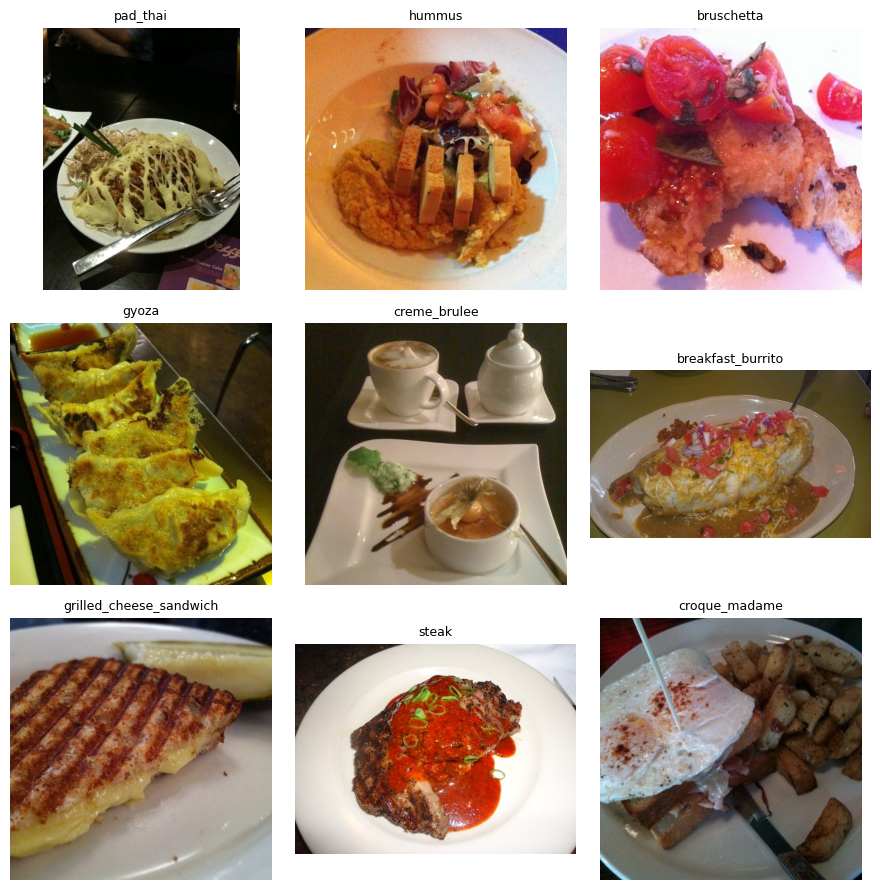

[EDA] Unique classes: 101  |  per-class count (should be ~1000): min=1000, max=1000


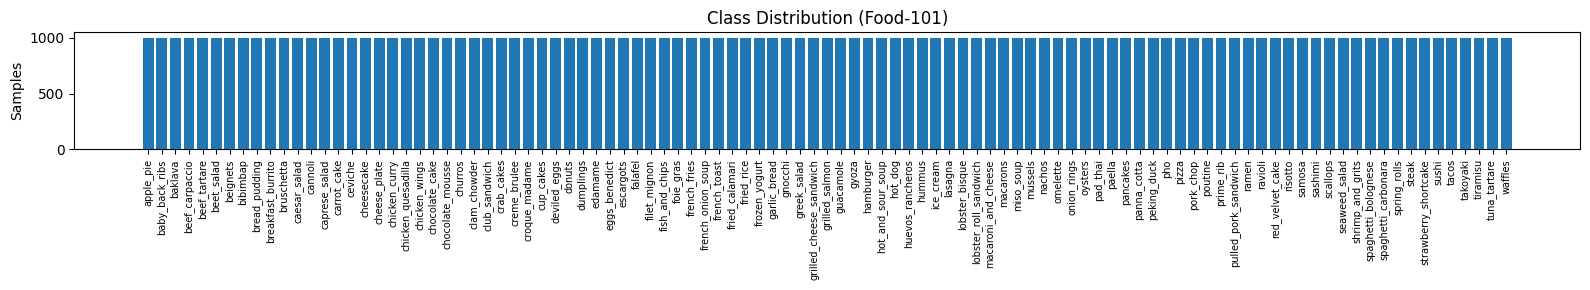

[EDA] Duplicate-hash groups (sampled first 5k): 5  (full dedup will occur in cleaning)


In [ ]:
# ============================================
# EDA: load summary, features, examples, balance, duplicates
# ============================================

# Basic dataset info
print(f"[Load] Total images: {len(food_all):,} | Classes: {len(food_label_names)}")
print("[Features]:", list(food_all.features.keys()))
print("[First 3 entries (id → name, size)]:")
for i in range(3):
    y = food_all[i][label_col]
    print(f"  row {i}: id={y:3d}  name={food_label_names[y]:<24}  image_size={food_all[i]['image'].size}")

# Sample grid
n, cols, seed = 9, 3, 42
idxs = random.Random(seed).sample(range(len(food_all)), n)
rows = math.ceil(n/cols)
plt.figure(figsize=(3*cols, 3*rows))
for i, idx in enumerate(idxs, 1):
    ex = food_all[idx]
    plt.subplot(rows, cols, i)
    plt.imshow(ex["image"]); plt.axis("off")
    plt.title(food_label_names[ex["label"]], fontsize=9)
plt.tight_layout()
plt.show()

# Class distribution (Food-101 is balanced by design)
label_ids = food_all["label"]
counts = Counter(label_ids)
print(f"[EDA] Unique classes: {len(set(label_ids))}  |  per-class count (should be ~1000): "
      f"min={min(counts.values())}, max={max(counts.values())}")

# bar plot
plt.figure(figsize=(16, 3))
plt.bar(range(len(food_label_names)), [counts[i] for i in range(len(food_label_names))])
plt.xticks(range(len(food_label_names)), food_label_names, rotation=90, fontsize=7)
plt.ylabel("Samples")
plt.title("Class Distribution (Food-101)")
plt.tight_layout()
plt.show()

# Duplicates (exact pixel dupes) — report only (dedup happens later in cleaning cell)
dup_hashes = {}
dup_count = 0
for i in range(0, min(len(food_all), 5000)):  # sample subset for speed; full check happens in cleaning cell
    h = hashlib.md5(np.array(food_all[i]['image']).tobytes()).hexdigest()
    dup_hashes.setdefault(h, 0); dup_hashes[h] += 1
dup_groups_sample = sum(1 for v in dup_hashes.values() if v > 1)
print(f"[EDA] Duplicate-hash groups (sampled first 5k): {dup_groups_sample}  (full dedup will occur in cleaning)")

In [ ]:
# ============================================
# Cleaning + stratified split + leakage checks
# ============================================

# Remove corrupted (defensive; Food-101 rarely has any)
corrupted_indices = [i for i in range(len(food_all)) if is_corrupted(food_all[i])]
print(f"[Clean] Corrupted detected: {len(corrupted_indices)}")
if corrupted_indices:
    keep_idx = sorted(set(range(len(food_all))) - set(corrupted_indices))
    food_all = food_all.select(keep_idx)

# Deduplicate exact pixel matches (keep first)
seen = set()
keep_idx = []
for i in range(len(food_all)):
    h = hash_image_fast(food_all[i]["image"])
    if h not in seen:
        seen.add(h)
        keep_idx.append(i)
if len(keep_idx) != len(food_all):
    print(f"[Clean] Dedup removed: {len(food_all) - len(keep_idx)}")
    food_all = food_all.select(keep_idx)

print(f"[Clean] Post-clean size: {len(food_all)}")

# Stratified 80/10/10 split on the cleaned dataset
labels = np.array(food_all[label_col])

# Train vs temp (val+test)
train_idx, temp_idx = train_test_split(
    np.arange(len(food_all)),
    test_size=(1.0 - TRAIN_FRACTION),
    random_state=random_seed,
    stratify=labels
)

# Val vs test from temp (preserve class proportions)
temp_labels = labels[temp_idx]
val_rel = VAL_FRACTION / (VAL_FRACTION + TEST_FRACTION)
val_idx_rel, test_idx_rel = train_test_split(
    np.arange(len(temp_idx)),
    test_size=(1.0 - val_rel),
    random_state=random_seed,
    stratify=temp_labels
)

val_idx  = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

# Build HF Dataset splits
ds_train = food_all.select(sorted(train_idx))
ds_val   = food_all.select(sorted(val_idx))
ds_test  = food_all.select(sorted(test_idx))

print(f"[Split] Train: {len(ds_train)} | Val: {len(ds_val)} | Test: {len(ds_test)}")

# Leakage checks (ensure disjoint indices)
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
print("[Split] Leakage check: PASSED")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[Clean] Corrupted detected: 0
[Clean] Dedup removed: 60
[Clean] Post-clean size: 100940
[Split] Train: 80752 | Val: 10094 | Test: 10094
[Split] Leakage check: PASSED


In [ ]:
# ============================================
# Preprocess map → TF streaming datasets → augmentation
# ============================================

# Map: standardize images (RGB→resize→/255) in parallel
ds_train_proc = ds_train.map(preprocess_no_aug, num_proc=4)
ds_val_proc   = ds_val.map(preprocess_no_aug,   num_proc=4)
ds_test_proc  = ds_test.map(preprocess_no_aug,  num_proc=4)

# Stream into tf.data to avoid building giant NumPy arrays in RAM
BATCH_SIZE = 32

train_ds = ds_train_proc.to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    shuffle=True,
    batch_size=BATCH_SIZE,
)
val_ds = ds_val_proc.to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    shuffle=False,
    batch_size=BATCH_SIZE,
)
test_ds = ds_test_proc.to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    shuffle=False,
    batch_size=BATCH_SIZE,
)

# Light augmentation on train only (flip); rotation optional later if tfa installed
def augment_fn(x, y):
    x = tf.image.random_flip_left_right(x)
    return x, y

train_ds = train_ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


[Split] Train=80752  Val=10094  Test=10094  (seed=42, stratified)
[Tensor] batch shape: (32, 224, 224, 3)  dtype: <dtype: 'float32'>
[Tensor] value range after normalization: [0.000, 1.000] (expect ~[0.0, 1.0])
[Preview] A few training samples after preprocessing/augmentation:


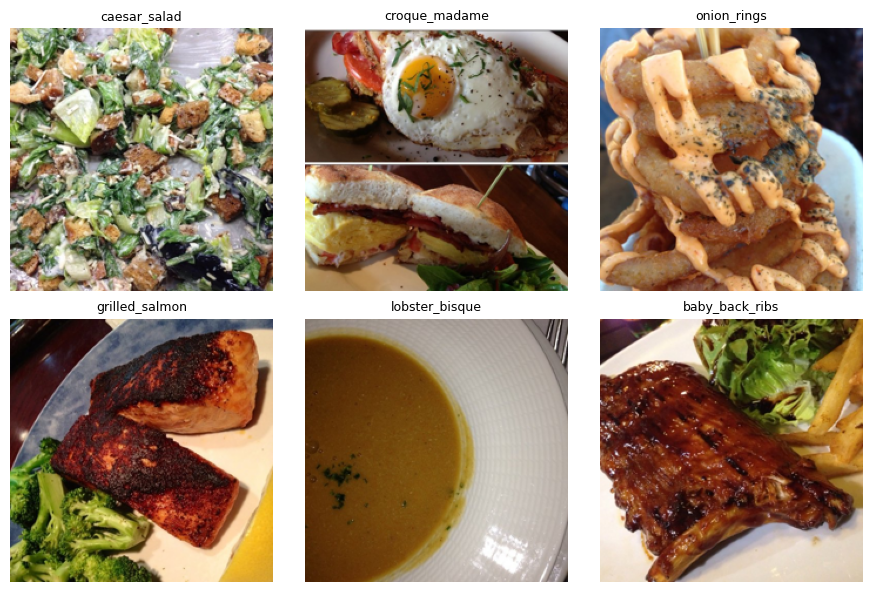

[Weights] near-uniform class_weights sample: {0: 1.0006567615459918, 1: 1.0019107173875281, 2: 0.9994059405940594, 3: 1.0006567615459918, 4: 1.0006567615459918}


In [ ]:
# ============================================
# Verification: normalization, shapes, augmentation, splits
# ============================================

# 1) Confirm split sizes & stratification intent
print(f"[Split] Train={len(ds_train)}  Val={len(ds_val)}  Test={len(ds_test)}  (seed=42, stratified)")

# 2) Confirm preprocess → tensor stats (values in [0,1], shapes 224x224x3)
for xb, yb in train_ds.take(1):
    print(f"[Tensor] batch shape: {xb.shape}  dtype: {xb.dtype}")
    x_min, x_max = float(tf.reduce_min(xb)), float(tf.reduce_max(xb))
    print(f"[Tensor] value range after normalization: [{x_min:.3f}, {x_max:.3f}] (expect ~[0.0, 1.0])")

# 3) Visual check after preprocess+aug (flip only); label names shown
print("[Preview] A few training samples after preprocessing/augmentation:")
preview_batch(train_ds, n=6, class_names=food_label_names)

# 4) Class weights (documents balance handling)
unique_labels = np.arange(len(food_label_names))
cw = compute_class_weight(class_weight="balanced",
                          classes=unique_labels,
                          y=np.array(ds_train_proc["label"]))
class_weights = {int(k): float(v) for k, v in zip(unique_labels, cw)}
print("[Weights] near-uniform class_weights sample:", dict(list(class_weights.items())[:5]))

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**



- The Food-101 dataset contains 101,000 with image–label pairs across 101 classes.
- Preprocessing the dataset confirmed consistent RGB mode, i.e., no gray-scaled images, resized images to a fixed 224×224 size, and normalized pixel values to [0,1].
- A corruption screen attempted round-trip conversion (RGB -> resize -> array) and dropped any failures.
- Exact duplicate images were detected via an MD5 hash over pixel arrays and only the first occurrence was retained, removing a small number of duplicate-hash groups.
- All cleaning occurred before computing labels for splitting to avoid index/label misalignment.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**



- The preprocessing pipeline converts PIL images to float32 arrays and scales by 1/255 to stabilize optimization and ensure consistent input range.
- Spatial standardization to 224×224 supports fixed-shape tensors and compatibility with CNNs.
- Light data augmentation is applied to the training split only (random horizontal flip; rotation optional), improving robustness to minor viewpoint changes without altering validation/test distributions.
- No text tokenization is used for this image-only task. A small preview of post-transform samples verifies that colors, aspect handling, and labels remain correct.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**



- After cleaning the dataset, an 80/10/10 split into train/validation/test using train_test_split with random_state=42 was done and stratify=labels was done to preserve class proportions.
- Splitting was performed in two stages (train vs. temp; temp into val/test) to maintain exact ratios.
- Leakage checks included recomputing labels from the cleaned dataset, verifying non-overlapping index sets between splits, and confirming that class distributions in each split matched the global distribution within rounding error.
- Subset sizes were also printed to document reproducibility.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**



The Food-101 is almot balanced with ~1,000 images per class across 101 categories. Post-cleaning counts remained effectively balanced (only negligible deviations due to the duplicate images removal). Class weights were computed from the training split for completeness and found to be uniform. So, no oversampling or rebalancing was necessary. Light augmentation on the training set provides diversity without distorting class priors. Label counts and per-split histograms confirm balance and support stratified evaluation.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

### Added common methods for training and testing

In [ ]:
# Mixed precision for A100
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

In [ ]:
def plot_learning_curves(hist, title, verbose=True, save_path=None, track_results=True):
    """
    Plots training/validation loss and accuracy curves, and logs summary statistics.

    Parameters:
        hist: Keras History object
        title: Plot title and identifier for results tracking
        verbose: If True, print final stats
        save_path: If set, saves the plot image to this path
        track_results: If True, updates global 'results' dictionary
    """
    val_losses = hist.history.get('val_loss')
    val_accuracies = hist.history.get('val_accuracy')
    train_losses = hist.history.get('loss')
    train_accuracies = hist.history.get('accuracy')

    if val_losses is None or train_losses is None:
        raise ValueError("Missing 'loss' or 'val_loss' in training history.")

    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)

    val_acc_at_min_loss = val_accuracies[min_val_epoch] if val_accuracies else None

    epochs = range(1, len(val_losses) + 1)
    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, train_losses, label='Train Loss')
    axs[0].plot(epochs, val_losses, label='Val Loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='Min Val Loss')
    axs[0].set_title(f'{title} - Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    if train_accuracies and val_accuracies:
        axs[1].plot(epochs, train_accuracies, label='Train Acc')
        axs[1].plot(epochs, val_accuracies, label='Val Acc')
        axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='Acc @ Min Val Loss')
        axs[1].set_title(f'{title} - Accuracy')
        axs[1].set_ylabel('Accuracy')
        axs[1].set_ylim(0, 1.05)
        axs[1].legend()
        axs[1].grid(True)
    else:
        axs[1].axis('off')  # Hide second plot if accuracy missing

    axs[1].set_xlabel('Epoch')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {train_losses[-1]:.4f}")
        print(f"Final Validation Loss:          {val_losses[-1]:.4f}")
        if train_accuracies:
            print(f"Final Training Accuracy:        {train_accuracies[-1]:.4f}")
        if val_accuracies:
            print(f"Final Validation Accuracy:      {val_accuracies[-1]:.4f}")
            print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
            print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    if track_results and val_acc_at_min_loss is not None:
        results[title] = (val_acc_at_min_loss, min_val_epoch + 1)

    return {
        "min_val_loss": min_val_loss,
        "val_acc_at_min_loss": val_acc_at_min_loss,
        "min_val_epoch": min_val_epoch + 1
    }


In [ ]:
def train_and_test(model,
                   train_ds,
                   val_ds,
                   test_ds,
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=128,
                   use_early_stopping=True,
                   patience=10,
                   min_delta=0.0001,
                   callbacks=[],
                   verbose=1,
                   return_history=False):
    """
    Trains a Keras model using tf.data.Datasets, applies early stopping, plots learning curves, and evaluates test performance.
    """
    print(f"\n{title}\n")
    model.summary()

    # Compile with dynamic optimizer
    if isinstance(optimizer, str):
        if optimizer == "Adam":
            opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
        else:
            raise ValueError(f"Unsupported optimizer: {optimizer}")
    else:
        opt = optimizer

    model.compile(optimizer=opt,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Callbacks
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    all_callbacks = [early_stop] + callbacks if use_early_stopping else callbacks

    # Start timer
    start = time.time()

    # Train
    history = model.fit(train_ds,
                        validation_data=val_ds,
                        epochs=epochs,
                        callbacks=all_callbacks,
                        verbose=verbose)

    # Best epoch tracking
    best_epoch = early_stop.best_epoch if use_early_stopping else np.argmin(history.history['val_loss'])
    best_acc = history.history['val_accuracy'][best_epoch]

    # Plot curves
    plot_learning_curves(history, title=title)

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: {format_hms(end - start)}")

    if return_history:
        return history


## **Model 1 – Baseline CNN Model**


### change flatten layer to GlobalAveragePooling2D due to the model execution performances.

In [ ]:
# Baseline model
NUM_CLASSES = len(food_label_names)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)


tf.keras.utils.set_random_seed(random_seed)

baseline = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(),
    GlobalAveragePooling2D(),  #change flatten to globalpooling
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation="softmax")
])


In [ ]:
train_and_test(baseline,
               train_ds, val_ds, test_ds,
               optimizer="Adam",
               epochs=100,
               title="Baseline Model with Food Image Dataset")


Baseline Model with Food Image Dataset



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │        13,029 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,789 (479.64 KB)

 Trainable params: 122,789 (479.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2524/2524 ━━━━━━━━━━━━━━━━━━━━ 29183s 12s/step - accuracy: 0.0204 - loss: 4.5315 - val_accuracy: 0.0604 - val_loss: 4.1642
Epoch 2/100
1351/2524 ━━━━━━━━━━━━━━━━━━━━ 3:19:50 10s/step - accuracy: 0.0586 - loss: 4.1828

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**



The baseline model is a small CNN with three Conv2D layers (32, 64, and 128 filters). Each of these layers are followed by MaxPooling to reduce spatial size while keeping intact the important visual patterns. After flattening, a Dense layer with dropout provides basic feature combination before the final softmax classification over the (101) food categories. This architecture suits the dataset because food images contain clear local texture and shape patterns that CNNs capture well, and the model is relatively small enough to train quickly without requiring large GPU memory utilization.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**



  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**



  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**



## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [ ]:
# --- Model: Deep CNN with widening blocks, BN, Dropout, Cosine LR ---

he = tf.keras.initializers.HeNormal()
num_classes = 101

def build_deep_cnn(input_shape=(224, 224, 3), num_classes=101):
    model = models.Sequential([
        tf.keras.Input(shape=input_shape),

        # --- Block 1 ---
        layers.Conv2D(32, 3, padding='same', kernel_initializer=he, use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        # --- Block 2 ---
        layers.Conv2D(64, 3, padding='same', kernel_initializer=he, use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),

        # --- Block 3 (new widening block) ---
        layers.Conv2D(128, 3, padding='same', kernel_initializer=he, use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(0.4),

        # --- Head ---
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_initializer=he),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


# Build the model
model_1 = build_deep_cnn(input_shape=(224,224,3), num_classes=num_classes)

# Define cosine-decay learning-rate schedule
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=800,
    t_mul=2.0,
    m_mul=0.8
)

# Train and evaluate
train_and_test(
    model=model_1,
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    epochs=30,                 # longer for deeper model
    lr_schedule=lr_schedule,   # integrates directly
    optimizer="Adam",
    title="Model – Deep CNN (32-64-128) + BN + Dropout + Cosine LR",
    patience=5,                # early stop if val_loss plateaus
    min_delta=1e-4,
    verbose=1
)


NameError: name 'tf' is not defined

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**



2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**



3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**



4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**



## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [ ]:
import tensorflow as tf

AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE   = (224, 224)
IMG_SHAPE  = (*IMG_SIZE, 3)

# ---- helpers ----
def _unwrap(x, y):
    # HF to_tf_dataset can emit dicts; normalize to (H,W,C) tensor + int label
    if isinstance(x, dict):
        x = x.get("pixel_values", x.get("image", x))
    x = tf.cast(x, tf.float32)
    # Fix shape (enables Keras to infer input rank)
    x = tf.ensure_shape(x, IMG_SHAPE)   # (H,W,C)
    y = tf.cast(y, tf.int32)
    return x, y

def _augment_single(x, y):
    x = tf.image.random_flip_left_right(x)
    return x, y

def _mbv2_preprocess(x, y):
    x = (x * 2.0) - 1.0                  # [0,1] -> [-1,1]
    return x, y

def _make_tf_stream(hf_split, shuffle):
    # Create UNBATCHED stream from HF split
    ds_tf = hf_split.to_tf_dataset(
        columns=["pixel_values"], label_cols=["label"],
        shuffle=shuffle, batch_size=None   # <-- key: no batching here
    )
    return (ds_tf
            .map(_unwrap, num_parallel_calls=AUTOTUNE))

# ---- rebuild datasets: unbatched -> map -> batch once ----
train_ds = (_make_tf_stream(ds_train_proc, shuffle=True)
            .map(_augment_single, num_parallel_calls=AUTOTUNE)
            .map(_mbv2_preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (_make_tf_stream(ds_val_proc, shuffle=False)
            .map(_mbv2_preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (_make_tf_stream(ds_test_proc, shuffle=False)
            .map(_mbv2_preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

# sanity check
for xb, yb in train_ds.take(1):
    print("train batch:", xb.shape)  # should be (B, 224, 224, 3)
    break


## **1. MobileNetV2 Model with freezing Head**

In [ ]:
def make_base_model_pooled(img_shape=(224, 224, 3),trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights='imagenet', include_top=False,
        input_shape=img_shape, pooling='avg'
    )
    base.trainable = trainable
    return base

base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({int(l.name.split('_')[1])
                    for l in base.layers if l.name.startswith('block_')})
print("Conv Block IDs:", block_ids, " (count:", len(block_ids), ")")

# Check if the final Conv_1 stage exists
has_conv1 = any(l.name.startswith('Conv_1') for l in base.layers)
print("Has Conv_1 stage:", has_conv1)
print('Model Output Shape:',base.output_shape)

In [ ]:
model_mobileNetV2_frozen = make_base_model_pooled()

rlrop = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


model_mobileNetV2_frozen = models.Sequential([
    model_mobileNetV2_frozen,
    Dense(NUM_CLASSES, activation='softmax')
])

In [ ]:
# Now call train_and_test()
train_and_test(
    model_mobileNetV2_frozen,
    train_ds, val_ds, test_ds,
    optimizer="Adam",
    lr_schedule=1e-3,
    epochs=20,
    title="Model with MobileNetV2 and Frozen Head",
    callbacks=[rlrop])

## **2. MobileNetV2 Model with Partialy Updated Head**

In [ ]:
## This method is used to create a partail unfreze model
def build_partial_unfreeze(N, dropout_rate=0.0, l2_lambda=0.0):
    # MobileNetV2
    base = make_base_model_pooled(trainable=True)
    # Freeze except the last N layers
    n_layers = len(base.layers)
    N_eff = max(0, min(N, n_layers))
    for layer in base.layers[: n_layers - N_eff]:
        layer.trainable = False
    head = []
    if dropout_rate and dropout_rate > 0:
        head.append(layers.Dropout(dropout_rate))
    if l2_lambda and l2_lambda > 0:
        head.append(layers.Dense(NUM_CLASSES, activation="softmax",
                                 kernel_regularizer=regularizers.l2(l2_lambda)))
    else:
        head.append(layers.Dense(NUM_CLASSES, activation="softmax"))

    model = models.Sequential([base] + head)
    return model

In [ ]:
# Experiment 3C: N=60, CosineDecay, light L2 on head
title = "Problem Partiol Unfresze — Exp 3: N=60 | CosineDecay 5e-5→0 | head=L2(3e-5)"
model_partial = build_partial_unfreeze(N=60, dropout_rate=0.0, l2_lambda=3e-5)

EPOCHS_EXP3 = 60
total_steps_exp3 = 2500 * EPOCHS_EXP3
cos_decay = CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=max(1, total_steps_exp3),
    alpha=0.0
)
opt = Adam(learning_rate=cos_decay)

hist_3C = train_and_test(
    model_partial,
    train_ds, val_ds, test_ds,
    title=title,
    optimizer=opt,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    use_early_stopping=True,
    patience=7,
    min_delta=1e-4,
    callbacks=[],
    return_history=True
)

## **3. MobileNetV2 Model with Unfrozon Head**

In [ ]:
title = "MobileNetV2 Model Unfrozon Head"

model_unfrozon = make_base_model_pooled(trainable=True)
model_unfrozon = models.Sequential([
    model_unfrozon,
    Dense(NUM_CLASSES, activation='softmax')
])

exp_decay = ExponentialDecay(
    initial_learning_rate=5e-5,
    decay_steps=max(1, steps_per_epoch * 5),
    decay_rate=0.90,
    staircase=False
)
opt2 = Adam(learning_rate=exp_decay)

hist2B = train_and_test(
    model_unfrozon,
    train_ds, val_ds, test_ds,
    title=title,
    optimizer='Adam',
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    use_early_stopping=True,
    patience=5,
    min_delta=5e-4,
    callbacks=[],
    return_history=True
)

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**



2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**



## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**